# **Eniac AB Testing**

## 1.Importing Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
pd.set_option("display.max_colwidth", None) #show unlimited size for screen
import seaborn as sns #import Seaborn library
from itertools import combinations #Post hoc to compare p

##2.Reading Files

In [ ]:
url = "https://drive.google.com/file/d/12nubhJXmQBw06jFdO43z1PUKyMxDEPQD/view?usp=sharing"
path_a = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]

url = "https://drive.google.com/file/d/1dNUMFWk1QtcRpFytd-HSY5Iz_6KMzDQ3/view?usp=sharing"
path_b = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]

url = "https://drive.google.com/file/d/1AUBvxBruhpJ3BoYDHOlcaTbPHMkviW5D/view?usp=drive_link"
path_c = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]

url = "https://drive.google.com/file/d/15wtlggI6bwsc9_zciy6MYq4yvlDJ2Vry/view?usp=drive_link"
path_d = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]

eniac_a = pd.read_csv(path_a)
eniac_b = pd.read_csv(path_b)
eniac_c = pd.read_csv(path_c)
eniac_d = pd.read_csv(path_d)

##3.Exploring data

In [ ]:
print("Version A")
display(eniac_a.head())

print("Version B")
display(eniac_b.head())

print("Version C")
display(eniac_c.head())

print("Version D")
display(eniac_d.head())

Version A


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • https://eniac.com/index-a.php
1,25,div,mySidebar,309,True,"created 2021-09-14 • 14 days 0 hours 34 mins • 25326 visits, 23174 clicks"
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN


Version B


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,236,True,Homepage Version B - red SHOP NOW • https://eniac.com/index-b.php
1,25,div,mySidebar,304,True,"created 2021-10-27 • 14 days 0 hours 34 mins • 24747 visits, 22407 clicks"
2,4,a,Mac,268,True,NaN
3,69,a,iPhone,260,True,NaN
4,105,a,Accessories,1214,True,NaN


Version C


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,288,True,Homepage Version C - white SEE DEALS • https://eniac.com/index-c.php
1,25,div,mySidebar,283,True,"created 2021-10-27 • 14 days 0 hours 34 mins • 24876 visits, 23031 clicks"
2,4,a,Mac,262,True,NaN
3,69,a,iPhone,234,True,NaN
4,105,a,Accessories,1288,True,NaN


Version D


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,285,True,Homepage Version D - red SEE DEALS • https://eniac.com/index-d.php
1,25,div,mySidebar,305,True,"created 2021-10-27 • 14 days 0 hours 34 mins • 25233 visits, 22743 clicks"
2,4,a,Mac,274,True,NaN
3,69,a,iPhone,243,True,NaN
4,105,a,Accessories,1267,True,NaN


### 3.1.Click extracting

In [ ]:
#finding (SHOP NOW or SEE DEALS)button in "Name" column and click rate in "No.clicks" column
#defin a funtion to find buttons
def show_click_number(data):
    #find a SHOP NOW or SEE DEALS buttons
    mask_ctr = data["Name"].astype(str).str.contains("SHOP NOW|SEE DEALS")
    return data.loc[mask_ctr]
#show ctr per buttons
display(show_click_number(eniac_a))
display(show_click_number(eniac_b))
display(show_click_number(eniac_c))
display(show_click_number(eniac_d))

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,106,a,SHOP NOW,512,True,NaN


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,126,a,SHOP NOW,281,True,NaN


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,127,a,SEE DEALS,527,True,NaN


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
21,128,a,SEE DEALS,193,True,NaN


In [ ]:
#define funtion to find clicks rate for SHOP NOW and SEE DEALS buttons
def find_click_button(data):
    #find a SHOP NOW or SEE DEALS buttons
    mask = data["Name"].astype(str).str.contains("SHOP NOW|SEE DEALS")
    button_row = data.loc[mask]
    #return integer of number of clicks
    return int(button_row["No. clicks"].iloc[0])

###3.2.Visitor extracting

In [ ]:
#define funtion to find numbers of visitors
#sample="created 2021-09-14 • 14 days 0 hours 34 mins • 25326 visits, 23174 clicks"
def find_visitor(data):
    #find mySidebar row
    sidebar_row = data.loc[data['Name'] == 'mySidebar','Snapshot information'].iloc[0]
    #split
    parts = sidebar_row.split('•')
    #find visits and clicks in last part
    last_part = parts[-1].strip()
    #split last part to seperate clicks and visits
    visits_part = last_part.split(',')[0].strip()
    #serate numbers from string
    visits_number = visits_part.split()[0]

    return int(visits_number)

### 3.3.Summery

In [ ]:
#create dataframe to show visits,clicks and no_clicks table
data_by_version = {
    "A": eniac_a,
    "B": eniac_b,
    "C": eniac_c,
    "D": eniac_d
}
#new list to save visits,clicks and no_clicks table
summary = []

for version, data in data_by_version.items():
    visits = find_visitor(data)
    clicks = find_click_button(data)
    no_clicks =visits -  clicks
 #add date to new list
    summary.append({
        "version": version,
        "visits": visits,
        "clicks": clicks,
        "no_clicks": no_clicks
    })

summary_df = pd.DataFrame(summary)
summary_df

,version,visits,clicks,no_clicks
0,A,25326,512,24814
1,B,24747,281,24466
2,C,24876,527,24349
3,D,25233,193,25040


##4.Metrics Calculating

###4.1.CTR for buttons

CTR = Click rate / visits

In [ ]:
#calculate Click-through rate according of clicks and visits
summary_df["CTR%"] = (summary_df['clicks'] / summary_df['visits']) * 100
summary_df

,version,visits,clicks,no_clicks,CTR%
0,A,25326,512,24814,2.021638
1,B,24747,281,24466,1.135491
2,C,24876,527,24349,2.118508
3,D,25233,193,25040,0.764871


####4.1.1.CTR graph

<BarContainer object of 4 artists>

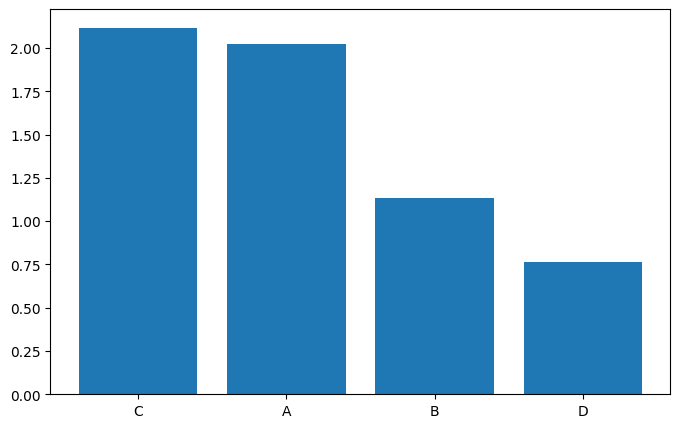

In [ ]:
#create chart with plot
plot_df = summary_df.sort_values("CTR%",ascending=False)
plt.figure(figsize=(8,5))
plt.bar(plot_df['version'],plot_df['CTR%'])

/tmp/ipykernel_965/1129575027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df,x='version',y='CTR%',palette=colors)


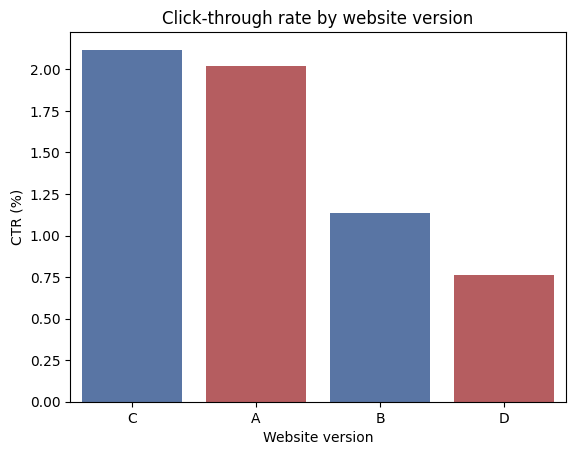

In [ ]:
#create chart with Seaborn
plot_df = summary_df.sort_values("CTR%",ascending=False)
colors = ['#4C72B0', '#C44E52', '#4C72B0', '#C44E52']
# blue = white button, red = red button
sns.barplot(data=plot_df,x='version',y='CTR%',palette=colors)

plt.title("Click-through rate by website version")
plt.xlabel("Website version")
plt.ylabel("CTR (%)")

plt.show()

#### 4.1.2. Results

Based on descriptive of CTA (graph) Version C shows the highest performance and Version D shows the worst performance. but without a statistical significant test, we could not tell whether these observed differences represent a real effect are due to random variation.

##5.Test

###5.1.Chi-squered Test

* **Null Hypothesis ($H_0$)**: The click rate on each website version (A, B, C, D) is equal.
* **Alternative Hypothesis ($H_A$)**: At least one of the versions has a significantly different click rate.

In [ ]:
#Collect data:
observed_results = pd.DataFrame(
    [
        summary_df["clicks"].tolist(),
        (
            summary_df["visits"] - summary_df["clicks"]
        ).tolist()
    ],
    index=["Click", "No-clicks"],
    columns=summary_df["version"]
)

observed_results

version,A,B,C,D
Click,512,281,527,193
No-clicks,24814,24466,24349,25040


In [ ]:
#Define siginficance level
alpha = 0.05

#Calculate the result test
chi2, p_value, df, expected = chi2_contingency(observed_results)
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p_value}")
print(f"Degrees of freedom: {df}")

#interpret the result
if p_value > alpha:
    print("The p-value is larger than alpha.Fail to reject the Null Hypothesis.There is not enough evidence to say the versions perform differently.")
else:
    print("The p-value is smaller than alpha.Reject the Null Hypothesis.There is a statistically significant difference between the button versions. ")

Chi-squared statistic: 224.01877488058412
P-value: 2.7161216607868712e-48
Degrees of freedom: 3
The p-value is smaller than alpha.Reject the Null Hypothesis.There is a statistically significant difference between the button versions. 


we reject the null hypothesis.CTR is not due to chance and it clearly depends on the version of the button.

### 5.2. Check expected frequencies

The chi-square test compares the observed click counts with counts that would be expected if all versions had the same click probability. Expected frequencies should not be too small.


In [ ]:
# rows = website versions, columns = click / no click
contingency_table = summary_df.set_index('version')[['clicks', 'no_clicks']]
contingency_table

,clicks,no_clicks
version,,
A,512,24814
B,281,24466
C,527,24349
D,193,25040


In [ ]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=['expected_clicks', 'expected_no_clicks']
)

expected_df.round(2)

NameError: name 'pd' is not defined

###5.3.Post hoc (Pair comparing)

The overall chi-square test only tells us that **at least one** version differs. It does not tell us which versions differ from each other. Therefore, we compare the versions pairwise.

Because six pairwise tests are performed, a **Bonferroni correction** is used to reduce the chance of false-positive findings.

we have 4 Version and would like to compare every pairs. so we should compare 6 pairs (3*4/2). (A-B, A-C, A-D, B-C, B-D, C-D)
we should to control Error type I (False Positive) , use Bonferroni.

In [ ]:
pairwise_results = []
versions = contingency_table.index.tolist()
number_of_comparisons = 6

for version_1, version_2 in combinations(versions, 2):
    pair_table = contingency_table.loc[[version_1, version_2]]
    chi2_pair, p_pair, _, _ = chi2_contingency(pair_table)

    adjusted_p = min(p_pair * number_of_comparisons, 1)

    pairwise_results.append({
        'comparison': f'{version_1} vs {version_2}',
        'p_value': p_pair,
        'adjusted_p_value': adjusted_p,
        'significant': adjusted_p < alpha
    })

pairwise_df = pd.DataFrame(pairwise_results)

#Calculate bonferroni threshold
number_of_comparisons = len(pairwise_df)
pairwise_df["alpha_bonferroni"] = 0.05 / number_of_comparisons
pairwise_df["significant"] = pairwise_df["p_value"] < pairwise_df["alpha_bonferroni"]
pairwise_df

,comparison,p_value,adjusted_p_value,significant,alpha_bonferroni
0,A vs B,2.673088e-15,1.603853e-14,True,0.008333
1,A vs C,4.648421e-01,1.000000e+00,False,0.008333
2,A vs D,3.080898e-33,1.848539e-32,True,0.008333
3,B vs C,6.955480e-18,4.173288e-17,True,0.008333
4,B vs D,2.357337e-05,1.414402e-04,True,0.008333
5,C vs D,6.450501e-37,3.870301e-36,True,0.008333


#### 5.3.1.Post-hoc interpretation

The post-hoc tests show that:

- Version A and Version C are not significantly different.
- Version C performs significantly better than Version B.
- Version C performs significantly better than Version D.
- Version A also performs significantly better than Versions B and D.

Therefore, Version C has the highest observed CTR, but it is not significantly better than Version A. The evidence supports choosing between Versions A and C rather than declaring Version C as the only clear winner.

**we should calculate other metrics (drop_off and home_return rate)**

####5.3.2.Drop_off and Home_return rate

In [ ]:
#Draw table for CTR, Drop_off and Home_return metrics

variants = ["A", "B", "C", "D"]
# CTR
ctr_percent = [2.02, 1.14, 2.12, 0.76]
# Drop-off rate (%)
dropoff_values = [62, np.nan, 71, 69] #LMS table
# Homepage-return rate (%)
home_return_values = [5.3, np.nan, 4.7, 2.6]#LMS table


metrics_df = pd.DataFrame({
    "version": variants,
    "CTR_percent": ctr_percent,
    "drop_off_rate": dropoff_values,
    "home_return_rate": home_return_values
})

metrics_df

,version,CTR_percent,drop_off_rate,home_return_rate
0,A,2.02,62.0,5.3
1,B,1.14,NaN,NaN
2,C,2.12,71.0,4.7
3,D,0.76,69.0,2.6


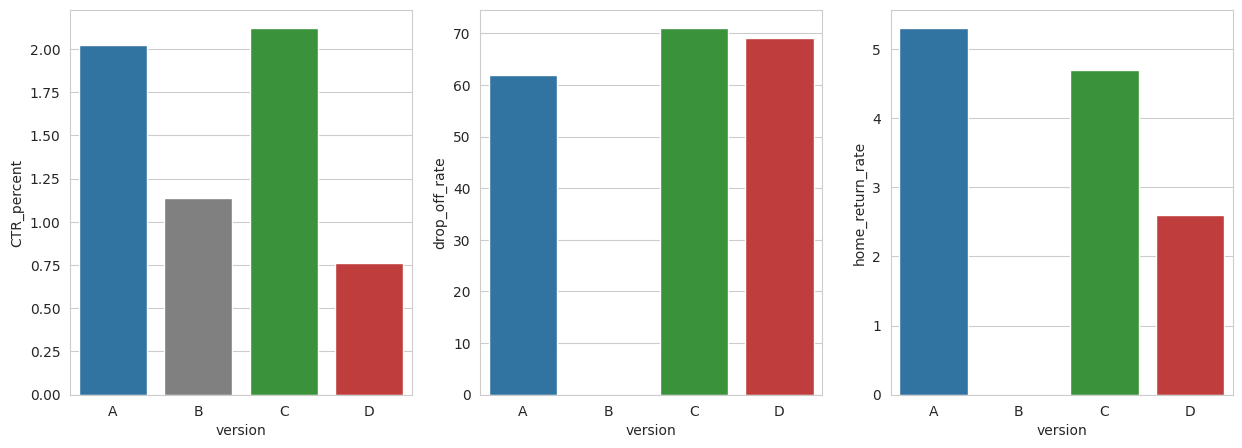

In [ ]:
from matplotlib import axes
sns.set_style ("whitegrid")
fig, axes = plt.subplots(1,3,figsize=(15,5))
palette = {
    "A": "#1f77b4",
    "B": "gray",
    "C": "#2ca02c",
    "D": "#d62728"
}
#CTR graph
sns.barplot(
    data=metrics_df,
    x="version",
    y="CTR_percent",
    hue="version",
    palette=palette,
    ax=axes[0]
)

#Drop_off graph
sns.barplot(
    data=metrics_df,
    x="version",
    y="drop_off_rate",
    hue="version",
    palette=palette,
    ax=axes[1]
)

#Home_return_rate graph
sns.barplot(
    data=metrics_df,
    x="version",
    y="home_return_rate",
    hue="version",
    palette=palette,
    ax=axes[2]
)

plt.show()

## 6. Conclusion

- **C (white SEE DEALS)** has the highest observed CTR at about **2.12%**.
- **A (white SHOP NOW)** is very close at about **2.02%**.
- The overall chi-square test is statistically significant, so the four CTRs are not all equal.
- However, the pairwise comparison **A vs C is not statistically significant**. Therefore, C cannot be declared a statistically proven improvement over the original A version.
- Both red-button variants perform clearly worse than the white-button variants.
- The observed uplift of C over A is only about **5% relative**, which is below the experiment's planned **20% MDE**.

**Business interpretation:** The experiment gives strong evidence against the red button, but it does not provide enough statistical evidence that changing the white button text from SHOP NOW to SEE DEALS improves CTR. Based on the available files, there is no statistically confirmed replacement for control A.

**Data limitation:** The downloaded CSVs support the CTR analysis, but not a reliable calculation of homepage-return rate or drop-off rate.